# July runs vs the best September run

**July**: the 2026-07-28 batch (full potential set, `terms2f1130a8`, many seeds) used before the September analyses.
**September**: `schedtest_adaptive_reg1e-4` (same full potential set, adaptive time grid), the best run of the 25-26 September tests.

**The two were fitted on different reference data.** July used `subseries_len=1024` (two Db3 coarse-grainings, n1=5000),
September `subseries_len=512` (one coarse-graining, n1=8500); both end at 256 points. So:
- every statistic is shown **relative to each group's own data** (ratio or difference), never one group against the other's data;
- tau = 1 is 4 original samples for July and 2 for September: this compares how well each run reproduces **its own target**, not which target is more physical.

The July seeds give the seed-to-seed spread (5-95% band), which a single September seed cannot. The dotted lines / 'data halves' rows are two disjoint halves of the same data against each other: the size of pure sampling noise (an upper guide, see `run_comparison.py`).

Plotting code lives in `run_comparison.py` (`plot_group_*`); this notebook only picks the runs.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from run_comparison import *

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.float_format', '{:.3g}'.format)
pd.set_option('display.max_colwidth', 40)

## Runs

In [2]:
NEW_NAME, NEW_LABEL, NEW_SEED = 'Sep 2ph full', 'schedtest_two_phase_reg1e-4', 900
JULY_NAME, JULY_PATTERN = 'July', '*_n1_5000_lam5e-07_seed_*_terms2f1130a8_20260728_1232*'
N_PDF = 5                  # July seeds pooled in the PDF plots (the September run has 8500 series)
THRESHOLD = 1e-8           # same as --moment_threshold

new_runs, missing = load_runs({NEW_NAME: NEW_LABEL}, seed=NEW_SEED)
if missing:
    print(pull_commands(missing))
    raise RuntimeError(f'{missing} not found locally: pull it first (command above)')
new = new_runs[NEW_NAME]
july_cfgs = find_configs(JULY_PATTERN)
assert july_cfgs, f'no saved samples match {JULY_PATTERN}'
july0 = load_config(july_cfgs[0], extras=False)
print(f"{NEW_NAME}: {new['config']}\n  {tuple(new['xt'].shape)}, {len(new['t']) - 1} steps, "
      f"t_end = {float(new['t'][-1]):.8f}, {new['runtime_h']:.1f} h")
print(f"{JULY_NAME}: {len(july_cfgs)} seeds, e.g. {july_cfgs[0]}\n  {tuple(july0['xt'].shape)}, "
      f"{len(july0['t']) - 1} steps, t_end = {float(july0['t'][-1]):.8f}")

Sep 2ph full: turbulencesynth_M256_J8_Q3_sigma3.5_nt60000_n1_8500_lam0.0_thomas_nsub1_f64_dedupfilt_seed_900_terms2f1130a8_schedtest_two_phase_reg1e-4_20260927_0005
  (8500, 256), 60000 steps, t_end = 0.99995000, 18.5 h
July: 51 seeds, e.g. turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232
  (5000, 256), 39705 steps, t_end = 0.99994558


### What differs between the two set-ups
All `config.json` keys whose values differ (keys absent on one side are shown as `-`).

In [3]:
a, b = july0['cfg'], new['cfg']
skip = {'timestamp', 'config_name', 'seed', 'outdir', 'reg_system_dir'}
diff = {k: (a.get(k, '-'), b.get(k, '-')) for k in sorted(set(a) | set(b))
        if k not in skip and a.get(k, '-') != b.get(k, '-')}
pd.DataFrame(diff, index=[JULY_NAME, NEW_NAME]).T.astype(str)

,July,Sep 2ph full
B,5000,8500
adapt_grow,-,1.2
adapt_h0,-,1e-05
adapt_h_max,-,0.001
adapt_ratio_max,-,0.001
adapt_ratio_min,-,1e-05
adapt_tol,-,0.001
batch_size,nan,5000.0
deduplicate_filters,-,True
gap_end,-,5e-05


## Reference data and statistics
One reference per group, rebuilt from its `config.json` exactly as `run_SDE.py` does. The July statistics are computed seed by seed and the samples dropped (only `N_PDF` seeds are kept for the PDF plots).

In [4]:
DATA_KEYS = ('n1', 'subseries_len', 'target_len')

def reference(cfg):
    x = reference_data(cfg)
    xa, xb = data_halves(x)
    return x, compute_stats(x), compute_stats(xa), compute_stats(xb)

x_new, S_new_ref, S_new_a, S_new_b = reference(new['cfg'])
x_jul, S_jul_ref, S_jul_a, S_jul_b = reference(july0['cfg'])
print('September data', tuple(x_new.shape), '| July data', tuple(x_jul.shape))

S_jul, x_jul_pdf = [], []
for c in july_cfgs:
    r = load_config(c, extras=False)
    if r['cfg']:
        assert all(r['cfg'].get(k) == july0['cfg'].get(k) for k in DATA_KEYS), f'{c}: different data'
    S_jul.append(compute_stats(r['xt']))
    if len(x_jul_pdf) < N_PDF:
        x_jul_pdf.append(r['xt'].numpy())
S_new = compute_stats(new['xt'])

def ks_rows(ref, S_list):
    df = wavelet_ks(ref, dict(enumerate(S_list)))
    return [df.loc[i] for i in range(len(S_list))]

groups = {
    JULY_NAME: dict(ref=S_jul_ref, runs=S_jul, ks=ks_rows(S_jul_ref, S_jul), color=PALETTE[1],
                    floor=S_jul_a, floor_ref=S_jul_b, floor_ks=wavelet_ks(S_jul_b, {'a': S_jul_a}).loc['a']),
    NEW_NAME: dict(ref=S_new_ref, runs=[S_new], ks=ks_rows(S_new_ref, [S_new]), color=PALETTE[0],
                   floor=S_new_a, floor_ref=S_new_b, floor_ks=wavelet_ks(S_new_b, {'a': S_new_a}).loc['a']),
}
print(f'{len(S_jul)} July seeds loaded')

September data (8500, 256) | July data (5000, 256)
51 July seeds loaded


## Summary
Each metric against the group's own data (ratios: 1 = perfect; `skew_diff` = gen - data; KS = Kolmogorov-Smirnov distance).
July: median [5%, 95%] across seeds. A September value inside the July interval is not distinguishable from July at one seed.

In [5]:
group_summary(groups)

,S2_ratio_tau1,flat4_ratio_tau1,flat6_ratio_tau1,skew_tau1,skew_diff_tau1,spec_logrms,marg_KS,wav_KS_max
July (n=51),"0.972 [0.97, 0.973]","1.03 [1.02, 1.04]","1.22 [1.16, 1.28]","0.0114 [-0.0579, 0.0642]","-0.0274 [-0.0968, 0.0253]","0.934 [0.927, 0.94]","0.0193 [0.015, 0.027]","0.782 [0.78, 0.785]"
data halves (July ref),0.985,1.13,1.93,0.0621,0.0459,0.114,0.0053,0.0182
Sep 2ph full (n=1),0.952,1.03,1.02,-0.0972,-0.0688,0.419,0.015,0.312
data halves (Sep 2ph full ref),1.05,1.09,1.49,-0.137,-0.225,0.248,0.012,0.0285


## Time series
Same y-scale within each block, not across the two (different data).

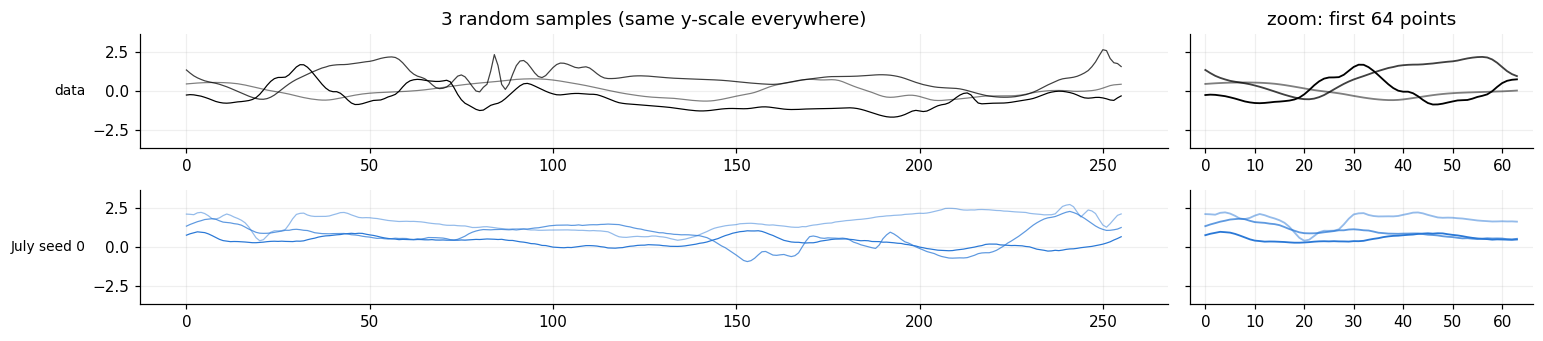

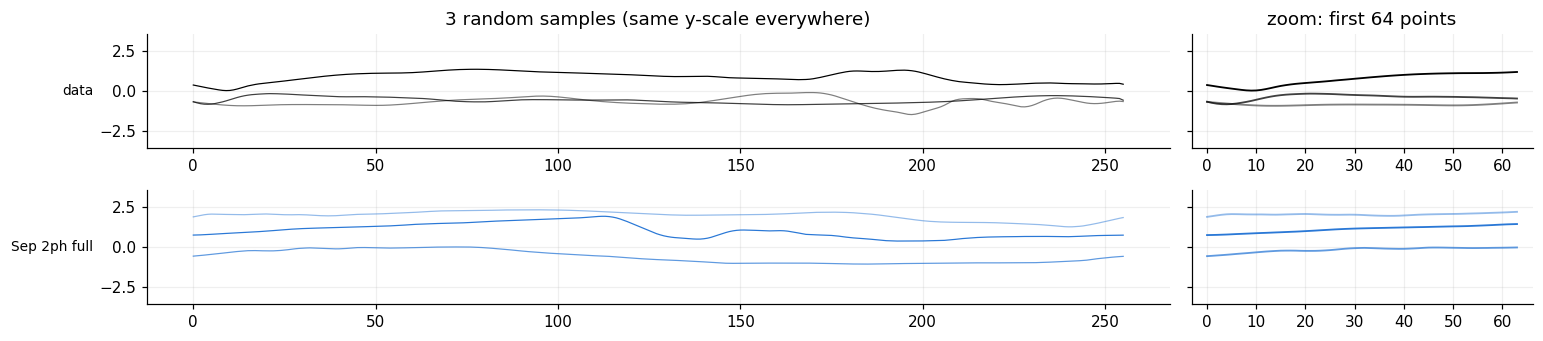

In [6]:
plot_time_series(x_jul, {f'{JULY_NAME} seed 0': dict(xt=torch.as_tensor(x_jul_pdf[0]))}, n=3, zoom=64)
plot_time_series(x_new, {NEW_NAME: new}, n=3, zoom=64)

## Power spectrum

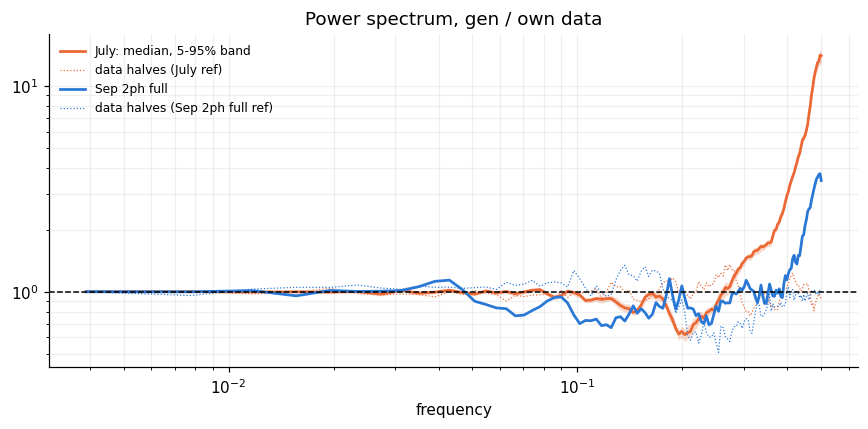

In [7]:
plot_group_spectra(groups)

## Structure functions, flatness, skewness
Skewness is shown as a difference: at these sample sizes it is dominated by noise (compare with the dotted data-halves line).

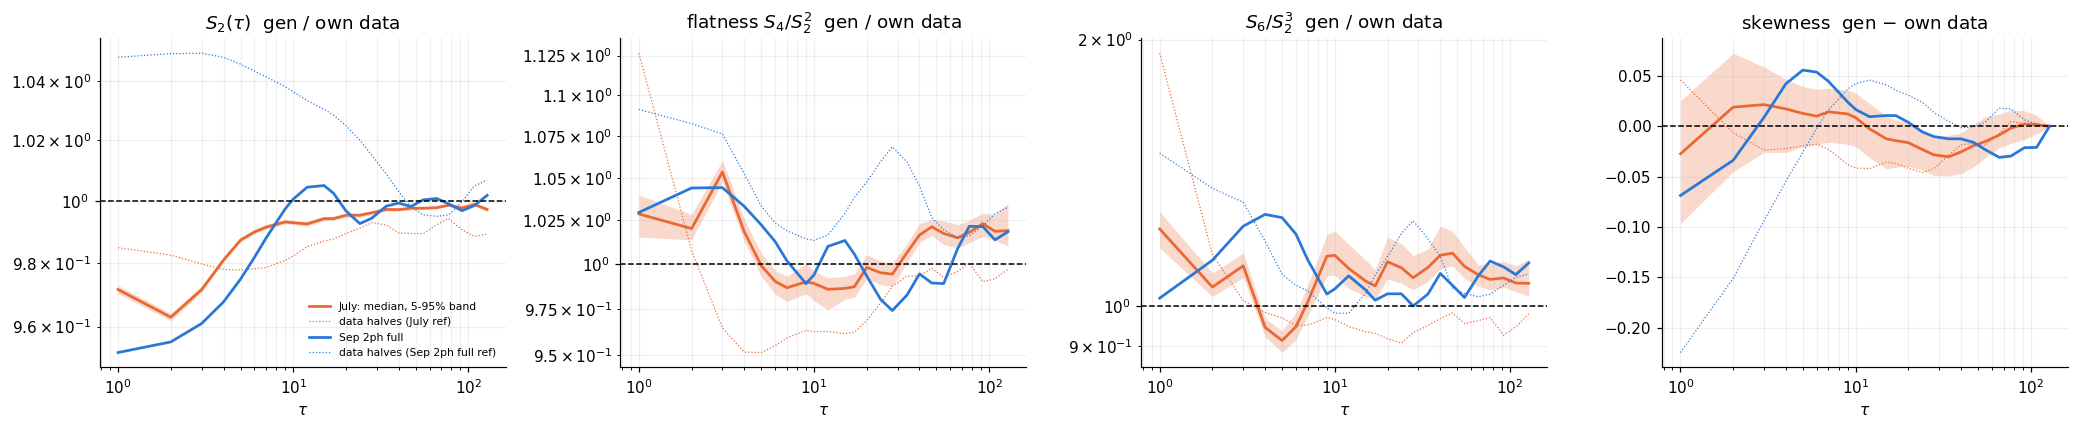

In [8]:
plot_group_structure(groups)

## Marginal and increment PDFs

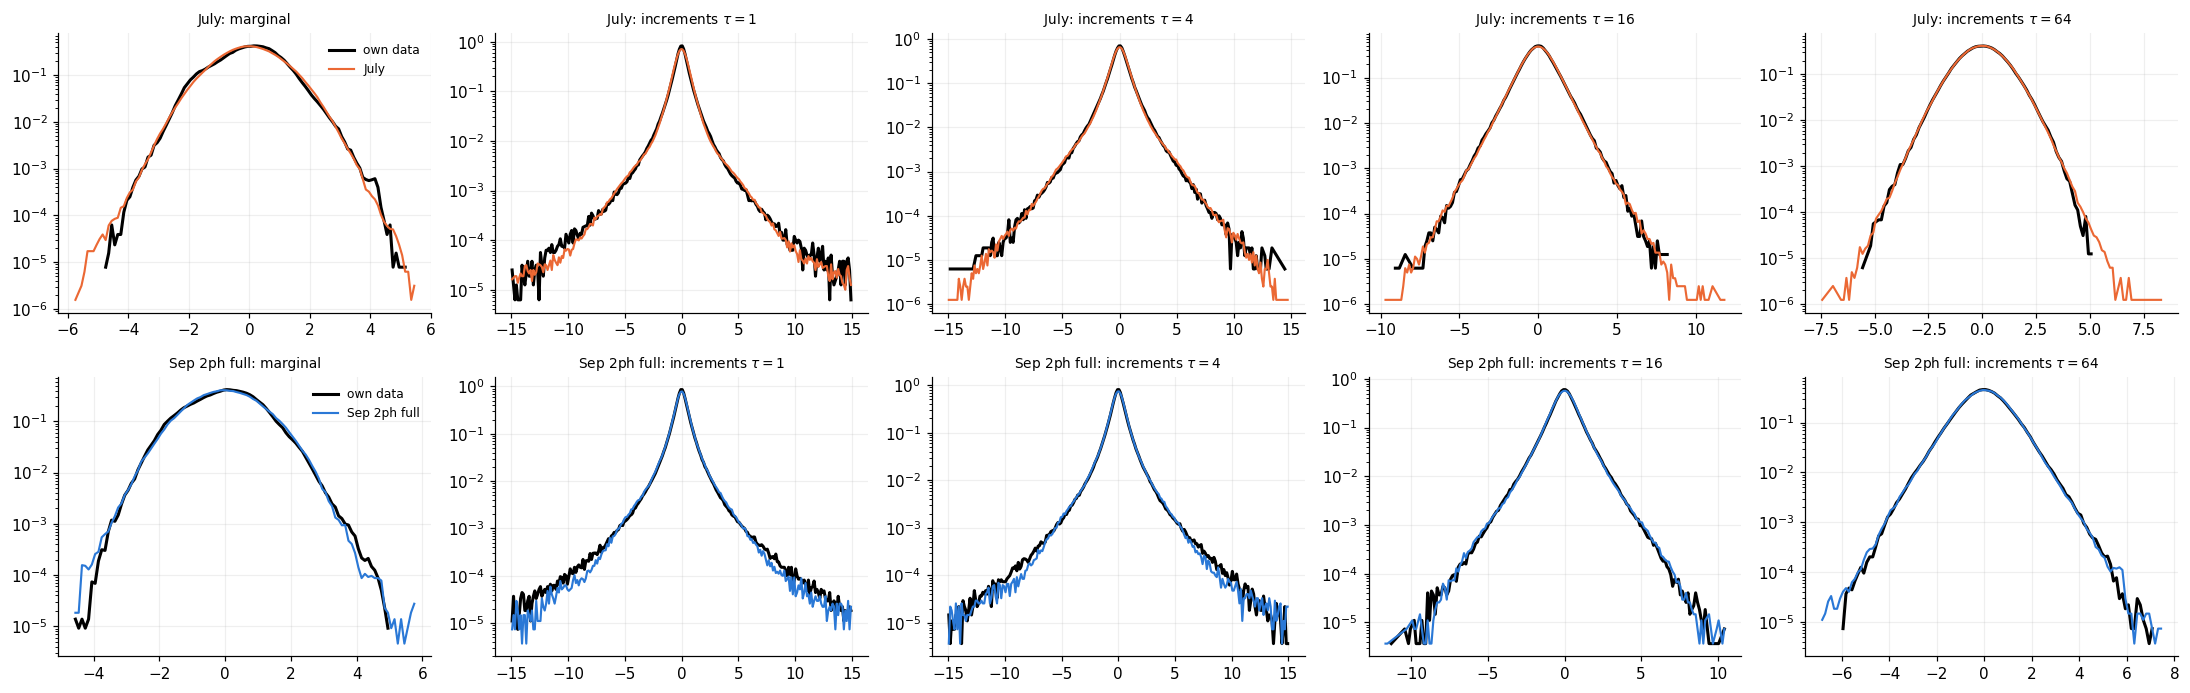

In [9]:
plot_group_pdfs(groups, {JULY_NAME: (x_jul, x_jul_pdf), NEW_NAME: (x_new, [new['xt'].numpy()])})

## Wavelet-band mismatch

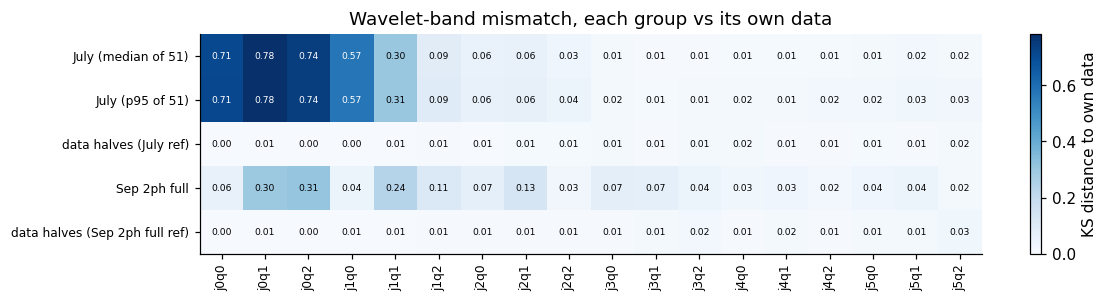

In [10]:
ks_table = plot_group_wavelet_ks(groups)

## Moment matching (only where aux moments are available)
The two runs match different moment sets (different reference data and fitted potentials), so compare the shapes of the curves, not the values moment by moment. The July aux moments may only exist on Jean Zay.

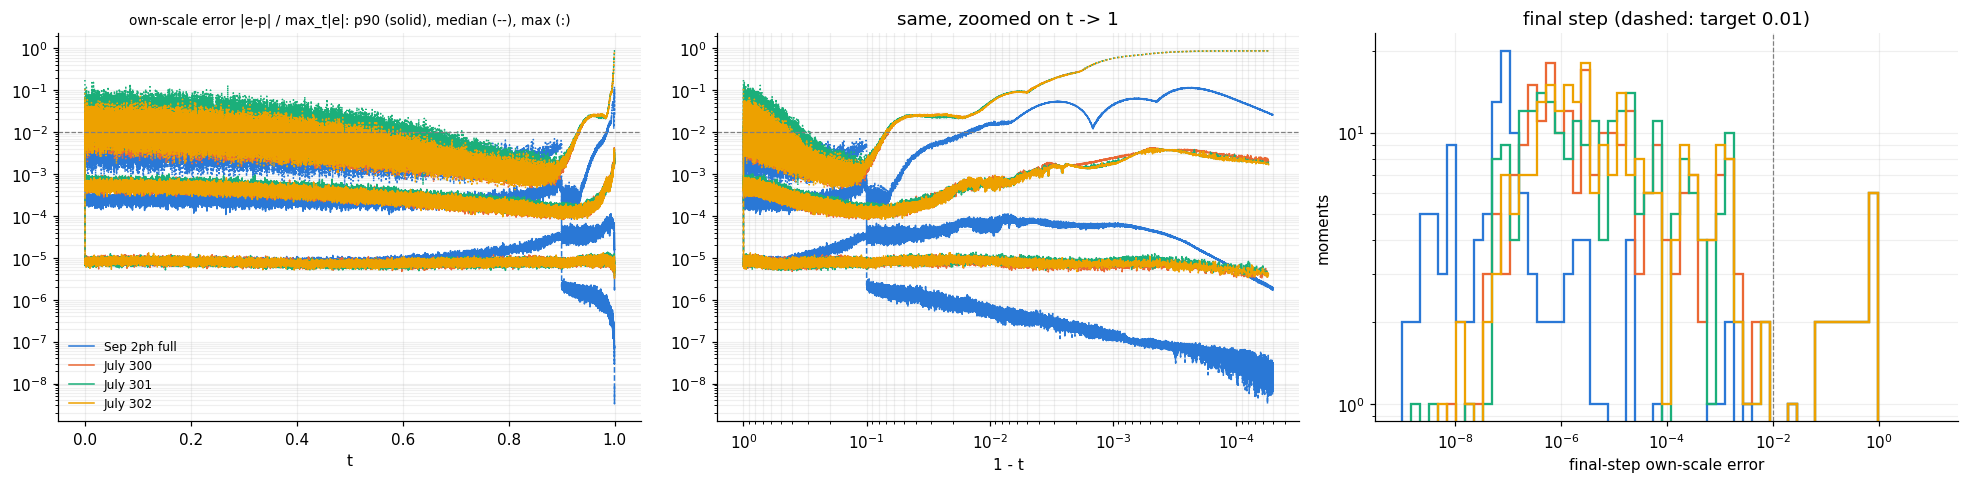

In [11]:
mm_runs = {NEW_NAME: new}
for c in july_cfgs[:3]:
    r = load_config(c)
    if 'barphi_e' in r:
        mm_runs[f"{JULY_NAME} {c.split('_seed_')[1].split('_')[0]}"] = r
if len(mm_runs) == 1:
    print('no July aux moments found locally')
plot_moment_matching(mm_runs, THRESHOLD)